# PyKoopman: Time Delays

> We use our training data to fit a DMD model by using time embeddings and a single trajectory.

#### Imports

In [254]:
from ast import literal_eval

import matplotlib.pyplot as plt
import matrepr
import numpy as np
import numpy.random as rnd
import pykoopman as pk
import torch
from matrepr import mprint
from pydmd import DMD, FbDMD
from safetensors.torch import load_file
from torch.nn import functional as F

from learningdynamics.dmd_data import reshape_append_time
from learningdynamics.utils import safetensors_metadata_parser

In [255]:
# | hide
np.random.seed(42)  # for reproducibility
%matplotlib inline

#### Load data

In [256]:
file_path = "../saved_weights/states.safetensors"

metadata = safetensors_metadata_parser(file_path=file_path)
NUM_TRAJECTORIES = literal_eval(metadata["NUM_TRAJECTORIES"])
NUM_STATES = literal_eval(metadata["NUM_STATES"])
NUM_ITERATIONS = literal_eval(metadata["NUM_ITERATIONS"])

data = load_file(file_path)

#### Update dataset

DMD Control panel

In [257]:
NUM_TRAJECTORIES = 10
NUM_STATES = 6
NUM_DELAYS = 11
RANK = 60

In [258]:
t = np.arange(0, NUM_ITERATIONS, 1)

#### Learn Koopman Operator

In [259]:
train_states = reshape_append_time(
    data["train_states"][:NUM_ITERATIONS, :NUM_TRAJECTORIES, :NUM_STATES]
)
test_states = reshape_append_time(data["test_states"][:NUM_ITERATIONS, :, :NUM_STATES])
observables = pk.observables.TimeDelay(delay=1, n_delays=NUM_DELAYS)

In [260]:
# Time shift data
X = train_states[:NUM_STATES, :-1].numpy()
Y = train_states[:NUM_STATES, 1:].numpy()

In [261]:
# regressor = pk.regression.EDMD(svd_rank=RANK)
# regressor = pk.regression.EDMD()
regressor = DMD(svd_rank=RANK)

dmd_model = pk.Koopman(observables=observables, regressor=regressor)
# dmd_model.fit(X.T, y=Y.T)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=11),
        regressor=PyDMDRegressor(regressor=<pydmd.dmd.DMD object at 0x7f9e2bef82b0>))

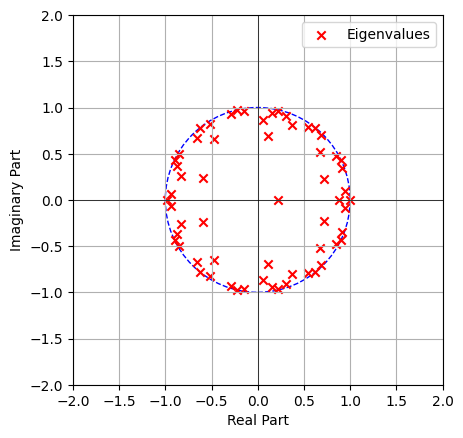

In [262]:
# Assuming koop_eigenvals is already defined
koop_eigenvals = np.diag(dmd_model.lamda)

# Create the figure and axis
fig, ax = plt.subplots()

# Plot the unit circle
unit_circle = plt.Circle((0, 0), 1, color="b", fill=False, linestyle="--")
ax.add_artist(unit_circle)

# Plot the eigenvalues
ax.scatter(
    koop_eigenvals.real, koop_eigenvals.imag, color="r", marker="x", label="Eigenvalues"
)

# Set the axis limits
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])

# Add grid, legend, and labels
ax.grid(True)
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Real Part")
ax.set_ylabel("Imaginary Part")
ax.legend()

# Show the plot
plt.show()

In [263]:
def predict_plot(states, sample, plot=True):
    x0_td = states[
        :NUM_STATES,
        sample * NUM_ITERATIONS : (sample * NUM_ITERATIONS) + NUM_DELAYS + 1,
    ].T.numpy()

    Xkoop = dmd_model.simulate(x0_td, n_steps=NUM_ITERATIONS - 1 - NUM_DELAYS)
    Xkoop = np.vstack([x0_td, Xkoop])

    if plot:
        fig, axs = plt.subplots(
            NUM_STATES, 1, sharex=True, tight_layout=True, figsize=(12, 6)
        )
        for state_idx in range(0, NUM_STATES):
            axs[state_idx].plot(
                t,
                states[
                    state_idx,
                    sample * NUM_ITERATIONS : sample * NUM_ITERATIONS + NUM_ITERATIONS,
                ],
                "-",
                color="b",
                label="True States",
            )
            axs[state_idx].plot(t, Xkoop[:, state_idx], "--r", label="Hankel DMD")
            axs[state_idx].set(ylabel=f"state {state_idx}")

        for i in range(0, NUM_STATES):
            axs[i].axvline(x=t[NUM_DELAYS])

    return Xkoop


def test_error(true_states, pred_states):
    loss = F.l1_loss(
        true_states[:, -1], torch.Tensor(pred_states).T[:, -1], reduction="sum"
    )
    return loss

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


6
Error: 3.510228157043457


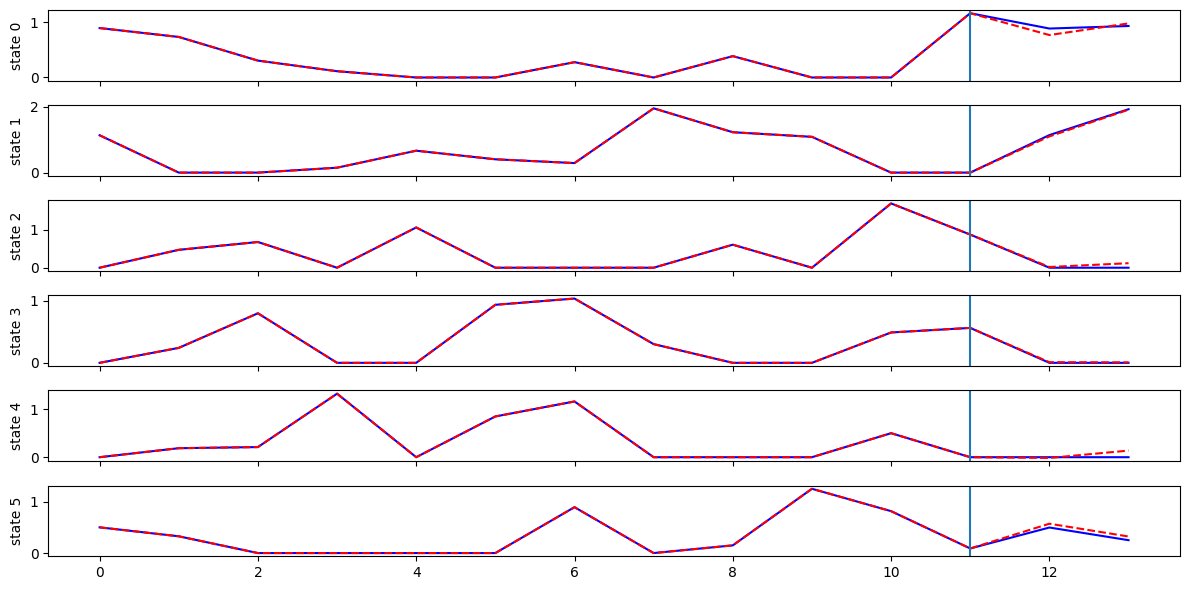

In [264]:
SAMPLE = np.random.choice(NUM_TRAJECTORIES)
Xkoop = predict_plot(train_states, 0)
error = test_error(
    true_states=train_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
)

print(SAMPLE)
print(f"Error: {error.item()}")

/opt/conda/lib/python3.10/site-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


435
Error: 0.6036312580108643


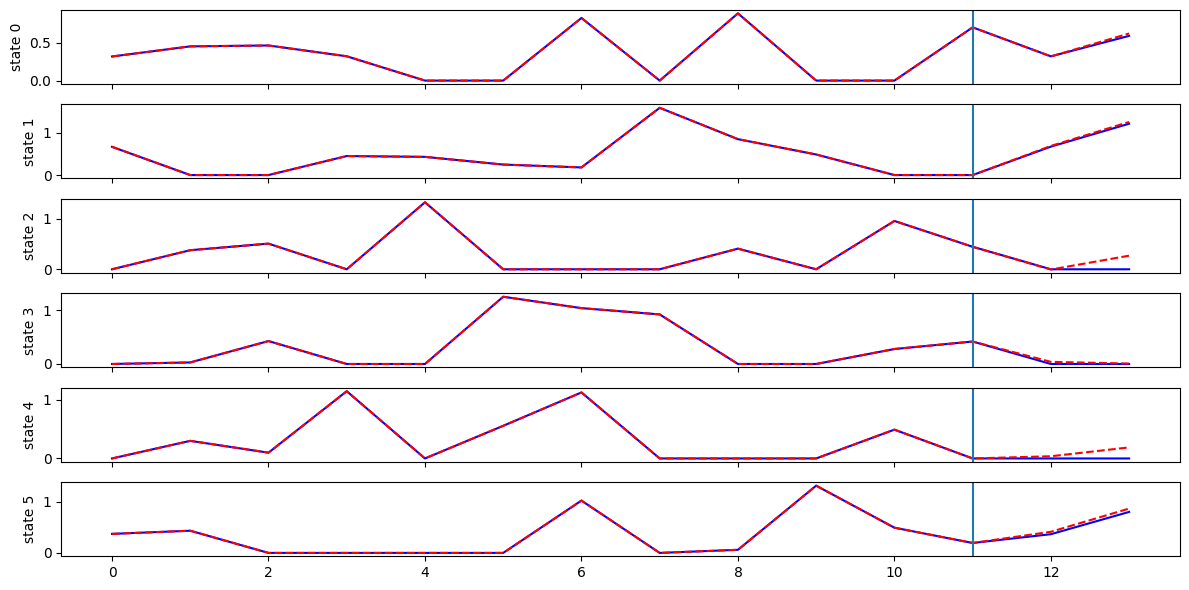

In [265]:
SAMPLE = np.random.choice(1000)
Xkoop = predict_plot(test_states, SAMPLE)
error = test_error(
    true_states=test_states[
        :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
    ],
    pred_states=Xkoop,
)

print(SAMPLE)
print(f"Error: {error.item()}")

In [266]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    errors = []
    for SAMPLE in range(1000):
        Xkoop = predict_plot(test_states, SAMPLE, plot=False)
        error = test_error(
            true_states=test_states[
                :, SAMPLE * NUM_ITERATIONS : SAMPLE * NUM_ITERATIONS + NUM_ITERATIONS
            ],
            pred_states=Xkoop,
        )
        errors.append(error)

    errors = torch.stack(errors)
    mean = torch.mean(errors)
    std = torch.std(errors)
    print(f"Mean Error {mean.item()}, Standard Dev {std.item()}")

Mean Error 0.5677563548088074, Standard Dev 0.27715691924095154


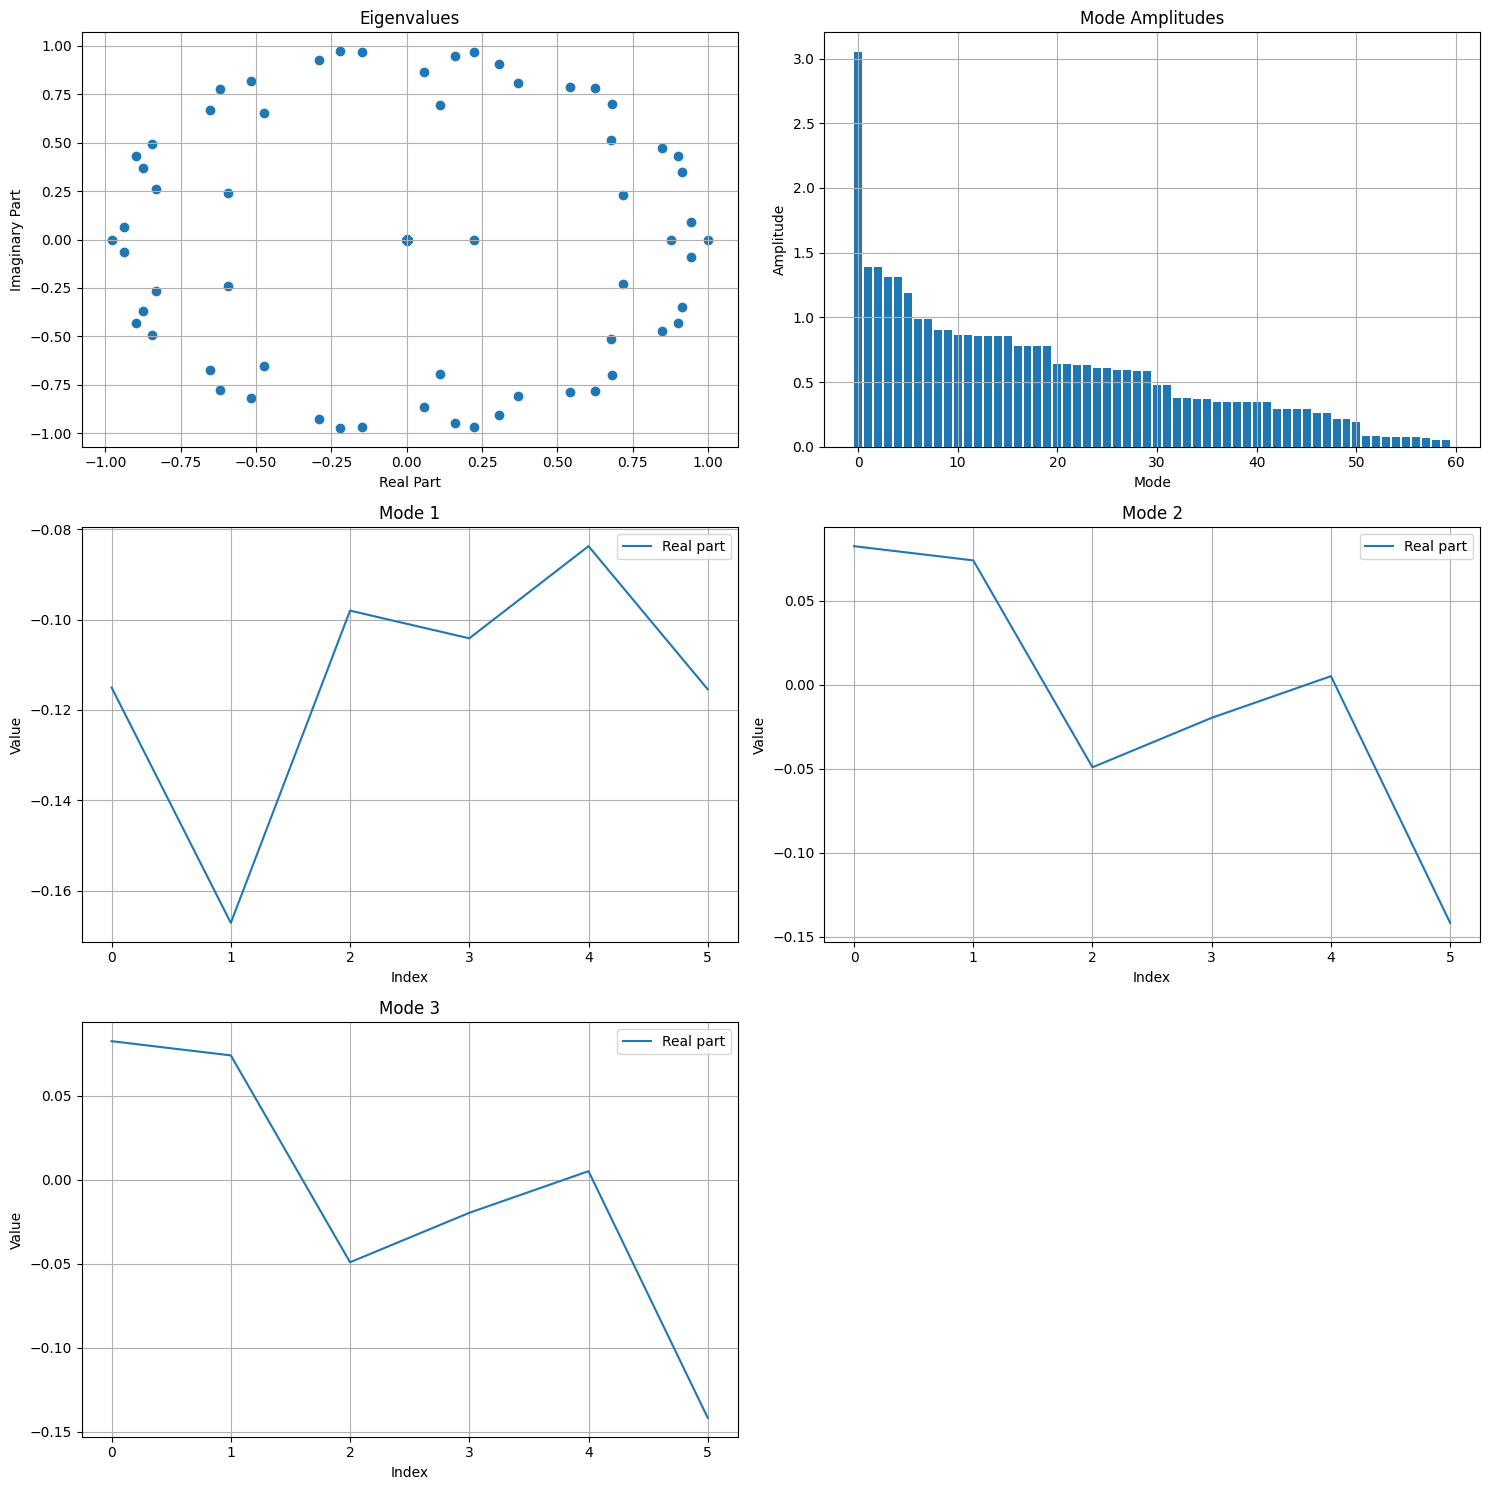

In [267]:
import numpy as np
import matplotlib.pyplot as plt


def plot_summary(dmd_model, k=5):
    # Sort modes by the magnitude of their amplitudes
    mode_order = np.argsort(-np.abs(dmd_model._amplitudes.flatten()), axis=0)

    # Extract leading eigenvalues, modes, and amplitudes
    lead_eigs = dmd_model.lamda[mode_order]
    lead_modes = dmd_model.W[:, mode_order]
    lead_amplitudes = np.abs(dmd_model._amplitudes.flatten()[mode_order])

    # Determine the number of rows required for the subplots
    n_plots = min(k, lead_modes.shape[1])
    n_rows = (n_plots + 1) // 2 + 1

    # Plot eigenvalues on the complex plane
    plt.figure(figsize=(15, 5 * n_rows))

    plt.subplot(n_rows, 2, 1)
    plt.scatter(np.real(lead_eigs), np.imag(lead_eigs), marker="o")
    plt.title("Eigenvalues")
    plt.xlabel("Real Part")
    plt.ylabel("Imaginary Part")
    plt.grid(True)

    # Plot leading mode amplitudes
    plt.subplot(n_rows, 2, 2)
    plt.bar(range(len(lead_amplitudes)), lead_amplitudes)
    plt.title("Mode Amplitudes")
    plt.xlabel("Mode")
    plt.ylabel("Amplitude")
    plt.grid(True)

    # Plot the real part of the top k modes
    for i in range(n_plots):
        plt.subplot(n_rows, 2, i + 3)
        mode = lead_modes[:, i]
        plt.plot(np.real(mode), label="Real part")
        plt.title(f"Mode {i + 1}")
        plt.xlabel("Index")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()


# Assuming dmd_model is already defined and contains the necessary attributes
plot_summary(dmd_model, k=3)